In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [5]:
#import 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split #데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt #학습과정 시각화

In [6]:
# 데이터 생성 및 전처리(라벨인코딩만 하고, 원핫인코딩X)

In [9]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target #라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

# 1. 기본적인 DNN(원핫인코딩X)

In [13]:
# model = Sequential()
# model.add(Input(4,))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model = Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary() # 250+1530+93 = 1837개 파라미터

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 50)                250       
                                                                 
 dense_9 (Dense)             (None, 30)                1530      
                                                                 
 dense_10 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [15]:
# 학습설정
model.compile(loss='sparse_categorical_crossentropy', #라벨인코딩만 되어있는 경우
             optimizer='adam',
             metrics=['accuracy'])
#학습
earlyStopping = EarlyStopping(patience=50) # monitor='val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000,
                validation_split=0.2,
                callbacks=[earlyStopping])

Epoch 1/1000
4/4 [==============================] - 1s 66ms/step - loss: 1.4573 - accuracy: 0.3611 - val_loss: 1.4246 - val_accuracy: 0.2222
Epoch 2/1000
4/4 [==============================] - 0s 18ms/step - loss: 1.1921 - accuracy: 0.3611 - val_loss: 1.2895 - val_accuracy: 0.2222
Epoch 3/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.0870 - accuracy: 0.3611 - val_loss: 1.2018 - val_accuracy: 0.2222
Epoch 4/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0476 - accuracy: 0.3796 - val_loss: 1.1383 - val_accuracy: 0.2963
Epoch 5/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0177 - accuracy: 0.3611 - val_loss: 1.0612 - val_accuracy: 0.2222
Epoch 6/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9669 - accuracy: 0.4167 - val_loss: 1.0007 - val_accuracy: 0.2593
Epoch 7/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.9320 - accuracy: 0.5093 - val_loss: 0.9475 - val_accuracy: 0.7037
Epoch 8/1000


Epoch 59/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1838 - accuracy: 0.9722 - val_loss: 0.1719 - val_accuracy: 0.9630
Epoch 60/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.1751 - accuracy: 0.9722 - val_loss: 0.1815 - val_accuracy: 0.9630
Epoch 61/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1735 - accuracy: 0.9722 - val_loss: 0.1708 - val_accuracy: 0.9630
Epoch 62/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1699 - accuracy: 0.9630 - val_loss: 0.1617 - val_accuracy: 0.9259
Epoch 63/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1672 - accuracy: 0.9815 - val_loss: 0.1620 - val_accuracy: 0.9630
Epoch 64/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.1605 - accuracy: 0.9815 - val_loss: 0.1582 - val_accuracy: 0.9630
Epoch 65/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1589 - accuracy: 0.9815 - val_loss: 0.1564 - val_accuracy: 0.9630
Epoch 

4/4 [==============================] - 0s 11ms/step - loss: 0.0854 - accuracy: 0.9815 - val_loss: 0.1031 - val_accuracy: 0.9630
Epoch 117/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0822 - accuracy: 0.9815 - val_loss: 0.0968 - val_accuracy: 0.9630
Epoch 118/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0808 - accuracy: 0.9907 - val_loss: 0.0953 - val_accuracy: 0.9259
Epoch 119/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0821 - accuracy: 0.9907 - val_loss: 0.0951 - val_accuracy: 0.9259
Epoch 120/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0814 - accuracy: 0.9815 - val_loss: 0.0952 - val_accuracy: 0.9259
Epoch 121/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0797 - accuracy: 0.9907 - val_loss: 0.0976 - val_accuracy: 0.9630
Epoch 122/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0792 - accuracy: 0.9815 - val_loss: 0.0964 - val_accuracy: 0.9630
Epoch 123/1000

4/4 [==============================] - 0s 12ms/step - loss: 0.0640 - accuracy: 0.9907 - val_loss: 0.0892 - val_accuracy: 0.9630
Epoch 174/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0629 - accuracy: 0.9907 - val_loss: 0.0853 - val_accuracy: 0.9259
Epoch 175/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0631 - accuracy: 0.9907 - val_loss: 0.0858 - val_accuracy: 0.9259
Epoch 176/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0667 - accuracy: 0.9815 - val_loss: 0.0848 - val_accuracy: 0.9259
Epoch 177/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0633 - accuracy: 0.9907 - val_loss: 0.0853 - val_accuracy: 0.9259
Epoch 178/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0608 - accuracy: 0.9907 - val_loss: 0.0939 - val_accuracy: 0.9630
Epoch 179/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0669 - accuracy: 0.9815 - val_loss: 0.0917 - val_accuracy: 0.9630
Epoch 180/1000

4/4 [==============================] - 0s 13ms/step - loss: 0.0561 - accuracy: 0.9815 - val_loss: 0.0838 - val_accuracy: 0.9259
Epoch 231/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.0586 - accuracy: 0.9907 - val_loss: 0.0867 - val_accuracy: 0.9630
Epoch 232/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0564 - accuracy: 0.9907 - val_loss: 0.0831 - val_accuracy: 0.9259
Epoch 233/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0553 - accuracy: 0.9907 - val_loss: 0.0830 - val_accuracy: 0.9259
Epoch 234/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.0610 - accuracy: 0.9815 - val_loss: 0.0824 - val_accuracy: 0.9259
Epoch 235/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0582 - accuracy: 0.9907 - val_loss: 0.0894 - val_accuracy: 0.9630
Epoch 236/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0597 - accuracy: 0.9907 - val_loss: 0.0826 - val_accuracy: 0.9259
Epoch 237/1000

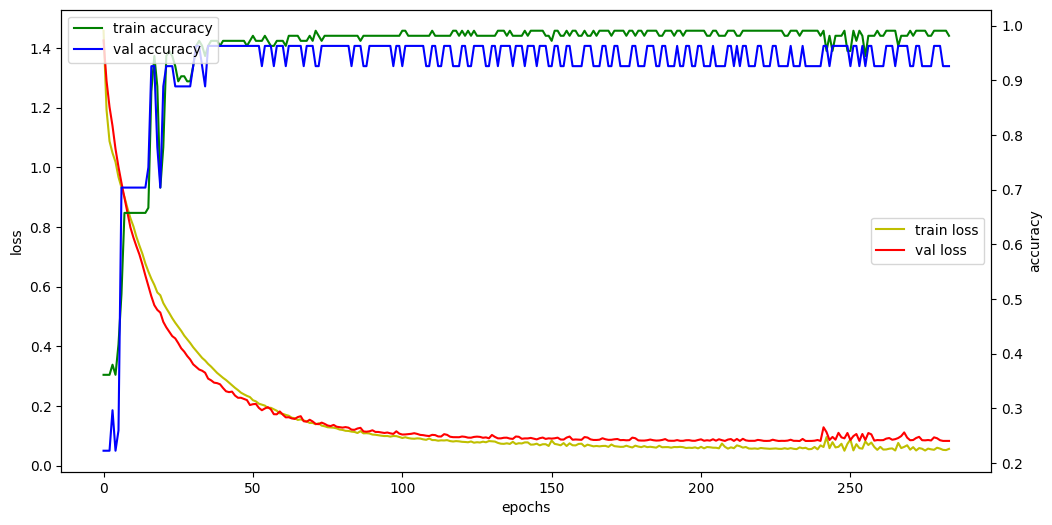

In [16]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(loc='upper left')
plt.show()

# 2. sklean이용
- 원핫인코딩을 하지 않고 라벨인코딩까지만 해야 작동. numpy배열

In [17]:
from sklearn.neural_network import MLPClassifier

In [22]:
# 머신러닝 3장 교안 43page
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 30),
                     activation='relu',
                     solver='adam',
                     alpha=0.0001, # 과적합 방지 강도
                     batch_size=40,
                     max_iter=1000, #epoch
                     early_stopping=True, # 조기 종료 활성화(val_loss)
                     n_iter_no_change=50, #patience
                     warm_start=False, #True일 경우 이전학습에 이어서 학습
                     validation_fraction=0.1) #검증셋 비율

In [23]:
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [32]:
#모델 평가 : accuracy(test_X, test_y), recall, precision(test_y, yhat)
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y)
yhat = mlp_model.predict(test_X)
recall = recall_score(test_y, yhat, average='weighted')
precision = precision_score(test_y, yhat, average='weighted')
print('정확도:',accuracy)
print('재현율:',recall)
print('정밀도:',precision)
print('교차표\n',pd.crosstab(test_y,yhat, 
                         rownames=['실제'],
                         colnames=['예측']))

정확도: 1.0
재현율: 1.0
정밀도: 1.0
교차표
 예측  0  1  2
실제         
0   5  0  0
1   0  5  0
2   0  0  5


# 3. 클래스 이용

In [36]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(50, activation=activation))
#         model.add(Dense(30, activation=activation))
#         model.add(Dense(3, activation='softmax'))
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax')
        ])
        #모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        return model

In [37]:
%%time
#모델 
model = DNNClassifier.build(input_dim=4, activation='relu')
model.summary()
#모델 학습
hist = model.fit(train_X, train_y, 
                epochs=500,
                validation_split=0.2,
                verbose=0)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 50)                250       
                                                                 
 dense_15 (Dense)            (None, 30)                1530      
                                                                 
 dense_16 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
CPU times: total: 20.8 s
Wall time: 15.5 s


In [38]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 21ms/step - loss: 0.0459 - accuracy: 1.0000


(0.045873455703258514, 1.0)

# 4. 함수형 API이용하기
- 병렬처리 : 속도 높이려고
- 레지듀얼블록(Residual block) : 모델의 성능을 높이려고(자연어처리, 이미지처리)

In [39]:
#import 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split #데이터 분할(층화추출로)
from tensorflow.keras import Model #모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Input, add # add : 레지듀얼블록
from tensorflow.keras.layers import concatenate #병렬처리시
import matplotlib.pyplot as plt #학습과정 시각화

In [40]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target #라벨인코딩이 되어 있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.1,
                                                   stratify=iris_y,
                                                   random_state=4)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

In [43]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(dense1)
dense3 = Dense(units=3, activation='softmax')(dense2)
model1 = Model(inputs=input_, outputs=dense3)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=20,
         validation_split=0.2)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 50)                250       
                                                                 
 dense_15 (Dense)            (None, 30)                1530      
                                                                 
 dense_16 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
4/4 [==============================] - 0s 51ms/step - loss: 0.0625 - accuracy: 0.9815 - val_loss: 0.0875 - val_accuracy: 0.9259
Epoch 2/20
4/4 [==============================] - 0s 12ms/step - loss: 0.0462 - accuracy: 0.9815 - val_loss: 0.0889 - val_accuracy: 0.9259
Epoch 3/20
4/4 [======================

In [45]:
# 병렬처리
# 4 -> 160(50, 80, 30으로 병렬처리) -> 32 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x = concatenate([dense1, dense2, dense3])
#x = Dense(160, activation='relu')(input_)의 병렬처리
dense4 = Dense(32, activation='relu')(x)
output = Dense(3, activation='softmax')(dense4)
model = Model(inputs = input_, outputs=output)
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_31 (Dense)               (None, 50)           250         ['input_11[0][0]']               
                                                                                                  
 dense_32 (Dense)               (None, 80)           400         ['input_11[0][0]']               
                                                                                                  
 dense_33 (Dense)               (None, 30)           150         ['input_11[0][0]']               
                                                                                            

In [48]:
# 레지듀얼블록(Residual Block):딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때
input_ = Input(shape=(4,))
dense1 = Dense(50, activation='relu')(input_)
dense2 = Dense(50, activation='relu')(dense1)
dense3 = add([dense1, dense2])
output = Dense(3, activation='softmax')(dense3)
model = Model(inputs = input_, outputs=output)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=500,
         validation_split=0.2, verbose=0)

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_39 (Dense)               (None, 50)           250         ['input_13[0][0]']               
                                                                                                  
 dense_40 (Dense)               (None, 50)           2550        ['dense_39[0][0]']               
                                                                                                  
 add_1 (Add)                    (None, 50)           0           ['dense_39[0][0]',               
                                                                  'dense_40[0][0]']         

In [49]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 21ms/step - loss: 0.0221 - accuracy: 1.0000


[0.022107427939772606, 1.0]